# In-Depth Analysis of Air Quality Index (AQI) in Delhi

### Objective
This project performs an in-depth analysis of air pollution data in Delhi to understand pollutant behavior, seasonal trends, and statistical relationships between pollutants. The analysis aims to identify key pollution drivers and provide insights for environmental improvement.

### Dataset Description
The dataset contains hourly pollution measurements including PM2.5, PM10, NO2, CO, SO2, O3 and NH3.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

## Research Questions

This study aims to answer the following questions:

1 What are the major pollutants affecting air quality in Delhi?

2 How do pollution levels vary across different seasons?

3 Which pollutants show strongest relationship with PM2.5?

4 What time periods show peak pollution?

5 Which pollutants contribute most to pollution levels?

6 What statistical relationships exist between pollutants?

7 What insights can help improve air quality management?

In [4]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Load Dataset
df = pd.read_csv("delhiaqi.csv")

In [3]:
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


## Dataset Overview

This section examines the structure, size and quality of the dataset.

In [5]:
df.shape

(561, 9)

In [7]:
df.columns

Index(['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    object 
 1   co      561 non-null    float64
 2   no      561 non-null    float64
 3   no2     561 non-null    float64
 4   o3      561 non-null    float64
 5   so2     561 non-null    float64
 6   pm2_5   561 non-null    float64
 7   pm10    561 non-null    float64
 8   nh3     561 non-null    float64
dtypes: float64(8), object(1)
memory usage: 39.6+ KB


In [10]:
df.describe()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,3814.942210,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062
std,3227.744681,83.904476,42.473791,39.979405,61.073080,227.359117,271.287026,36.563094
min,654.220000,0.000000,13.370000,0.000000,5.250000,60.100000,69.080000,0.630000
25%,1708.980000,3.380000,44.550000,0.070000,28.130000,204.450000,240.900000,8.230000
50%,2590.180000,13.300000,63.750000,11.800000,47.210000,301.170000,340.900000,14.820000
75%,4432.680000,59.010000,97.330000,47.210000,77.250000,416.650000,482.570000,26.350000
max,16876.220000,425.580000,263.210000,164.510000,511.170000,1310.200000,1499.270000,267.510000


## Data Cleaning

Data cleaning ensures accuracy and consistency of analysis.
Steps performed:

- Removed duplicates
- Converted date column
- Extracted time features

In [13]:
df.drop_duplicates(inplace=True) # Remove duplicates

In [14]:
df['date']=pd.to_datetime(df['date']) # Convert date column

In [16]:
# Extract time features
df['year']=df['date'].dt.year 
df['month']=df['date'].dt.month
df['day']=df['date'].dt.day
df['hour']=df['date'].dt.hour

## Feature Engineering

New variables were created to improve analysis:

- Season classification
- Pollution indicator

In [17]:
# Create season column

def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8]:
        return "Monsoon"
    else:
        return "Post-Monsoon"
df['season']=df['month'].apply(season)

# Using PM2.5 as pollution indicator
df['AQI']=df['pm2_5']

## Statistical Analysis

Basic statistical measures help understand pollution distribution.

In [18]:
pollutants=['co','no','no2','o3','so2','pm2_5','pm10','nh3']

In [19]:
df[pollutants].mean()

co       3814.942210
no         51.181979
no2        75.292496
o3         30.141943
so2        64.655936
pm2_5     358.256364
pm10      420.988414
nh3        26.425062
dtype: float64

In [20]:
df[pollutants].max()

co       16876.22
no         425.58
no2        263.21
o3         164.51
so2        511.17
pm2_5     1310.20
pm10      1499.27
nh3        267.51
dtype: float64

In [21]:
df[pollutants].min()

co       654.22
no         0.00
no2       13.37
o3         0.00
so2        5.25
pm2_5     60.10
pm10      69.08
nh3        0.63
dtype: float64

## Time Series Analysis

Time analysis helps identify pollution trends.

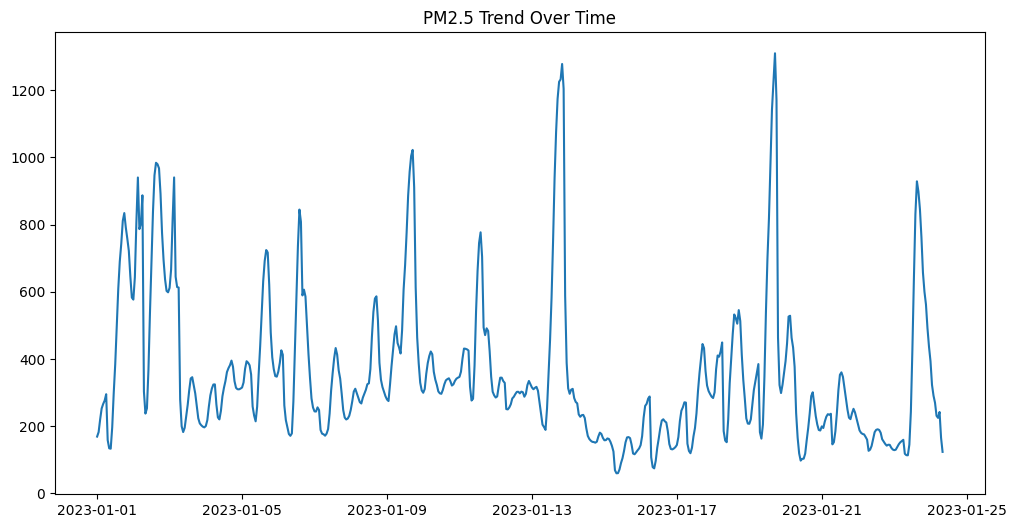

In [22]:
plt.figure(figsize=(12,6))
plt.plot(df['date'],df['pm2_5'])
plt.title("PM2.5 Trend Over Time")
plt.show()

## Seasonal Pollution Analysis

Seasonal analysis identifies how weather patterns affect pollution.

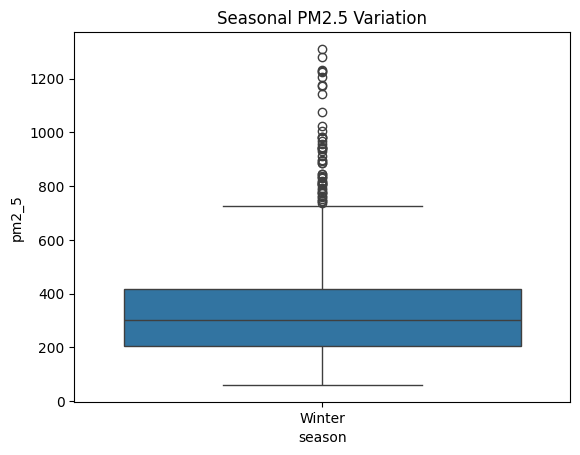

season
Winter    358.256364
Name: pm2_5, dtype: float64

In [23]:
sns.boxplot(x='season',y='pm2_5',data=df)
plt.title("Seasonal PM2.5 Variation")
plt.show()
df.groupby('season')['pm2_5'].mean()

## Hourly Pollution Analysis

Hourly analysis identifies peak pollution hours.

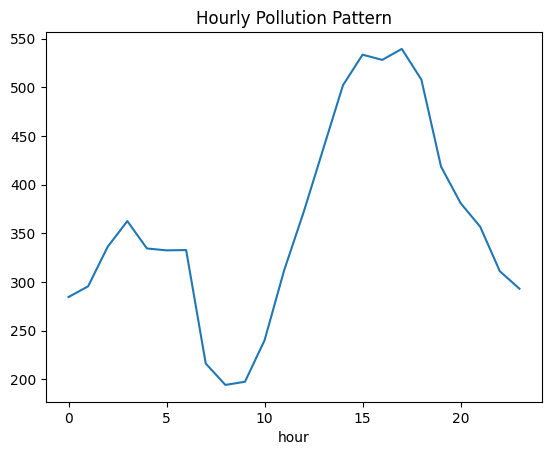

In [24]:
df.groupby('hour')['pm2_5'].mean().plot()
plt.title("Hourly Pollution Pattern")
plt.show()

## Correlation Analysis

Correlation analysis identifies relationships between pollutants.

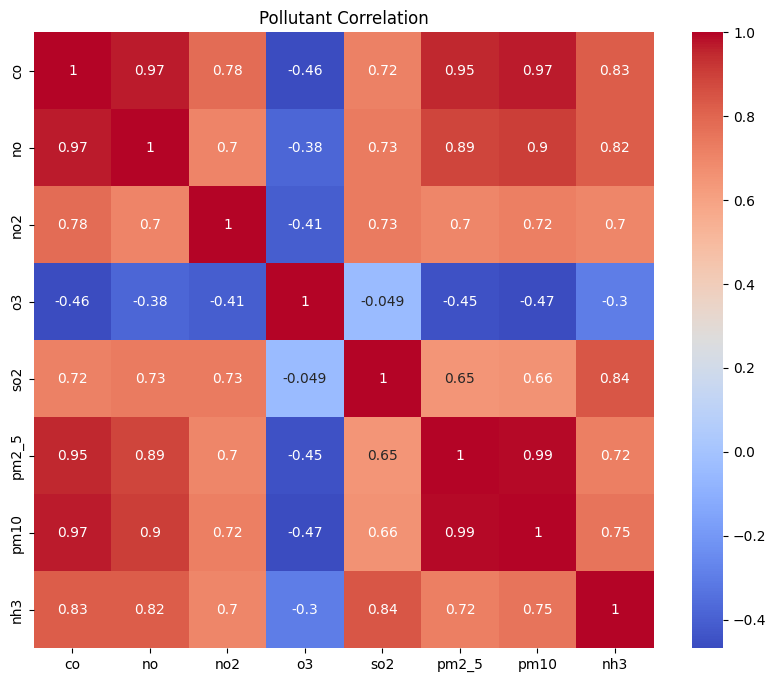

In [25]:
corr=df[pollutants].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Pollutant Correlation")
plt.show()

## Regression Analysis

Regression analysis was performed to identify pollutants that most strongly influence PM2.5 levels.

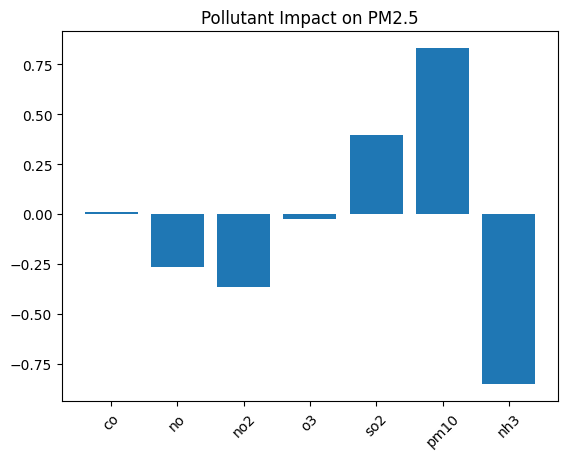

In [26]:
X=df[['co','no','no2','o3','so2','pm10','nh3']]
y=df['pm2_5']
model=LinearRegression()
model.fit(X,y)
importance=model.coef_
plt.bar(X.columns,importance)
plt.xticks(rotation=45)
plt.title("Pollutant Impact on PM2.5")
plt.show()

## Trend Analysis Using Moving Average

Moving averages help smooth fluctuations and identify long term trends.

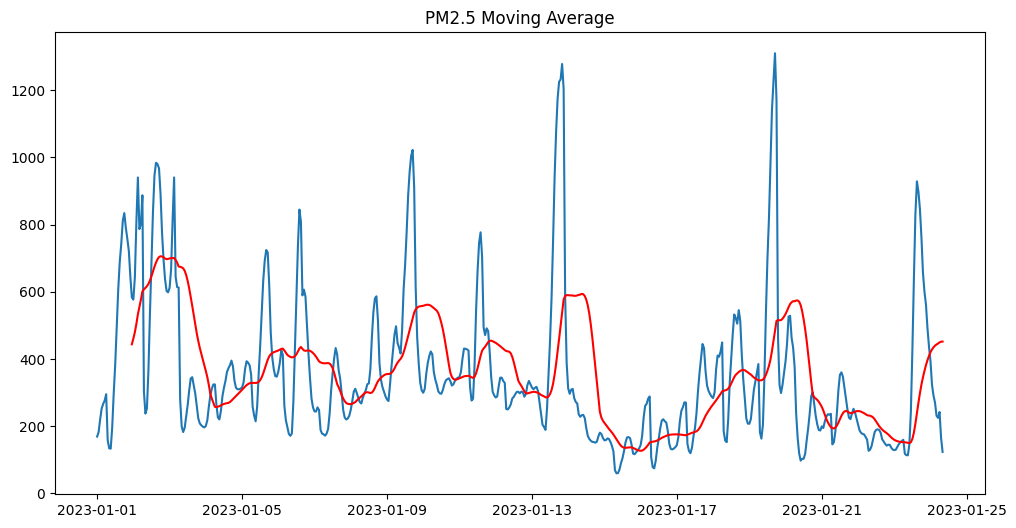

In [27]:
df['PM25_MA']=df['pm2_5'].rolling(24).mean()
plt.figure(figsize=(12,6))
plt.plot(df['date'],df['pm2_5'])
plt.plot(df['date'],df['PM25_MA'],color='red')
plt.title("PM2.5 Moving Average")
plt.show()

## Key Findings

Major observations from analysis:

- PM2.5 shows high variation across time
- PM10 shows strong correlation with PM2.5
- Winter shows highest pollution
- Pollution peaks during specific hours
- Some pollutants show weak relationships

These insights highlight major pollution contributors.

## Environmental Challenges in Delhi

Major pollution sources include:

- Vehicle emissions
- Industrial activities
- Construction dust
- Crop burning
- Weather inversion
- Urban congestion

## Recommendations

Based on analysis:

- Promote electric vehicles
- Improve emission control
- Dust management systems
- Smart pollution monitoring
- Public awareness programs

## Conclusion

This study analyzed pollution trends, pollutant relationships, and seasonal variations in Delhi. The findings identify major pollution drivers and provide insights useful for environmental policy and public health planning.

In [28]:
df.to_csv("processed_delhi_pollution.csv",index=False)